In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from bilby.gw.conversion import lambda_1_lambda_2_to_lambda_tilde, lambda_1_lambda_2_to_delta_lambda_tilde, lambda_tilde_delta_lambda_tilde_to_lambda_1_lambda_2

In [8]:
wide_df = pd.read_csv("../../events/gw/gw_params_wide.dat", sep=" ")
events = pd.read_csv("events.dat", sep=" ")
events["mass_ratio"] = events["mass_2"] / events["mass_1"]

In [3]:
n_coll = np.sum(events["prompt_collapse"] ==1 )
n_tot = events.shape[0]
pop_coll_share = np.sum(wide_df["prompt_collapse"]==1)/wide_df.shape[0]

print(f"Prompt collapse: {n_coll}/{n_tot}, {n_coll/n_tot:.3f}, ", pop_coll_share)

Prompt collapse: 17/43, 0.395,  0.7548668655397194


In [4]:
log10_mej_wind = events["log10_mej_wind"]
zeta = 10**(events["log10_mej_wind"] - events["log10_mdisk"])

print("wind quantile: ", np.quantile(log10_mej_wind, 0.05))
print("zeta quantile: ", np.quantile(zeta, 0.05))

wind quantile:  -2.023181953105709
zeta quantile:  0.1670274925572547


In [5]:
print("SNR min max: ", np.min(events["snr"]), np.max(events["snr"]))

SNR min max:  15.651 229.002


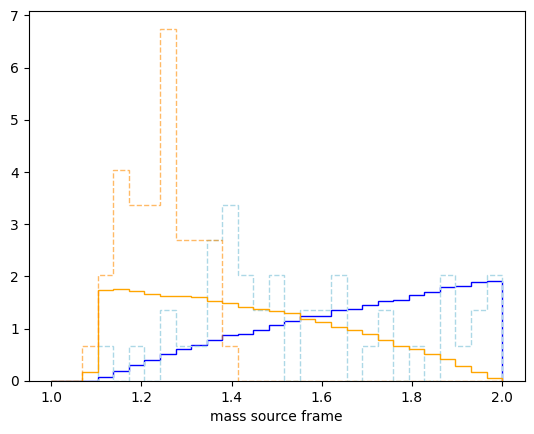

In [6]:
bins = np.linspace(1, 2, 30)

plt.hist(wide_df["mass_1_source"], bins=bins, density=True, histtype="step", color="blue")
plt.hist(events.loc[:, "mass_1_source"], bins=bins, density=True, histtype="step", color="lightblue", linestyle="dashed")

plt.hist(wide_df["mass_2_source"], bins=bins, density=True, color="orange", histtype="step")
plt.hist(events.loc[:, "mass_2_source"], bins=bins, density=True, histtype="step", alpha=0.6, color="darkorange", linestyle="dashed")


plt.xlabel("mass source frame")
plt.show()

In [9]:
events["mass_ratio"].min(), events["mass_ratio"].max()

(np.float64(0.5695349275251658), np.float64(0.9950413547935425))

In [13]:
events["chi_1"].min(), events["chi_1"].max()

(np.float64(-0.0870739585608745), np.float64(0.107184603837348))

In [14]:
events["chi_2"].min(), events["chi_2"].max()

(np.float64(-0.152444188008334), np.float64(0.1308321557988546))

In [15]:
events["luminosity_distance"].min(), events["luminosity_distance"].max()

(np.float64(277.7217813608225), np.float64(2689.1815191503533))